# Notebook 7 - Outlier Analysis

Dataset: `healthcare_dataset.csv`



In [50]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

df = pd.read_csv('healthcare_dataset.csv')
df['Date of Admission'] = pd.to_datetime(df['Date of Admission'])
df['Discharge Date'] = pd.to_datetime(df['Discharge Date'])
df['Length of Stay'] = (df['Discharge Date'] - df['Date of Admission']).dt.days
df.shape

(55500, 16)

In [51]:
df.head()

,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results,Length of Stay
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal,2
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive,6
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal,15
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal,30
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal,20


In [52]:
df.describe()

,Age,Date of Admission,Billing Amount,Room Number,Discharge Date,Length of Stay
count,55500.000000,55500,55500.000000,55500.000000,55500,55500.000000
mean,51.539459,2021-11-01 01:02:22.443243,25539.316097,301.134829,2021-11-16 13:15:20.821621,15.509009
min,13.000000,2019-05-08 00:00:00,-2008.492140,101.000000,2019-05-09 00:00:00,1.000000
25%,35.000000,2020-07-28 00:00:00,13241.224652,202.000000,2020-08-12 00:00:00,8.000000
50%,52.000000,2021-11-01 00:00:00,25538.069376,302.000000,2021-11-17 00:00:00,15.000000
75%,68.000000,2023-02-03 00:00:00,37820.508436,401.000000,2023-02-18 00:00:00,23.000000
max,89.000000,2024-05-07 00:00:00,52764.276736,500.000000,2024-06-06 00:00:00,30.000000
std,19.602454,NaN,14211.454431,115.243069,NaN,8.659600


## 1. What is an Outlier?

An outlier is a data point that lies far from the majority of other observations in a dataset. It deviates so much from the general pattern that it raises the question of whether it was generated by the same process as the rest of the data, a different process entirely, or a mistake in recording.

Outliers are not automatically wrong. Some are genuine, rare events. Others are the result of errors. The goal of this notebook is to detect unusual values in the healthcare dataset and reason about each one before deciding what to do with it.

## 2. Why Outliers Occur

Common causes:

- **Data entry errors** - typos, misplaced decimal points, wrong units, negative values where only positive values make sense
- **Measurement or system errors** - sensor faults, billing system glitches, rounding issues
- **Natural variability** - genuinely rare but valid cases, such as a very elderly patient or an unusually high medical bill for a complex procedure
- **Sampling issues** - a record that does not belong to the population being studied
- **Intentional or fraudulent entries** - inflated billing, incorrect insurance claims

Knowing the likely cause guides the decision on whether to remove, correct, transform, or keep a value.

## 3. Types of Outliers

- **Point (global) outliers** - a single value far from the rest of the data, e.g. a Billing Amount of -2000 when all other bills are positive
- **Contextual outliers** - a value that is unusual only in a specific context, e.g. a very short Length of Stay for a Cancer admission but normal for a routine checkup
- **Collective outliers** - a group of records that together deviate from the norm, e.g. a batch of records from one hospital with billing values that are all unusually low, suggesting a systemic entry issue rather than isolated mistakes

## 4. Univariate Outliers

Univariate outlier detection looks at one variable at a time, ignoring relationships with other columns. Here we examine `Age`, `Billing Amount`, `Room Number`, and `Length of Stay`.

In [53]:
numeric_cols = ['Age', 'Billing Amount', 'Room Number', 'Length of Stay']
df[numeric_cols].describe()

,Age,Billing Amount,Room Number,Length of Stay
count,55500.000000,55500.000000,55500.000000,55500.000000
mean,51.539459,25539.316097,301.134829,15.509009
std,19.602454,14211.454431,115.243069,8.659600
min,13.000000,-2008.492140,101.000000,1.000000
25%,35.000000,13241.224652,202.000000,8.000000
50%,52.000000,25538.069376,302.000000,15.000000
75%,68.000000,37820.508436,401.000000,23.000000
max,89.000000,52764.276736,500.000000,30.000000


### 4.1 IQR Method

The Interquartile Range (IQR) method flags a value as an outlier if it falls below `Q1 - 1.5*IQR` or above `Q3 + 1.5*IQR`.

In [54]:
def iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1
    lower = q1 - 1.5 * iqr
    upper = q3 + 1.5 * iqr
    return lower, upper

iqr_summary = {}
for col in numeric_cols:
    lower, upper = iqr_bounds(df[col])
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    iqr_summary[col] = {
        'lower_bound': lower,
        'upper_bound': upper,
        'num_outliers': len(outliers),
        'pct_outliers': round(len(outliers) / len(df) * 100, 3)
    }

pd.DataFrame(iqr_summary).T

,lower_bound,upper_bound,num_outliers,pct_outliers
Age,-14.500000,117.500000,0.0,0.0
Billing Amount,-23627.701023,74689.434111,0.0,0.0
Room Number,-96.500000,699.500000,0.0,0.0
Length of Stay,-14.500000,45.500000,0.0,0.0


### 4.2 Z-Score Method

The Z-Score method flags a value as an outlier if it lies more than a chosen number of standard deviations (commonly 3) from the mean. It assumes roughly normal distribution, so it is applied here as a cross-check against the IQR results rather than as the sole method.

In [55]:
from scipy import stats

zscore_summary = {}
for col in numeric_cols:
    z = np.abs(stats.zscore(df[col]))
    outliers = df[z > 3]
    zscore_summary[col] = {
        'num_outliers': len(outliers),
        'pct_outliers': round(len(outliers) / len(df) * 100, 3)
    }

pd.DataFrame(zscore_summary).T

,num_outliers,pct_outliers
Age,0.0,0.0
Billing Amount,0.0,0.0
Room Number,0.0,0.0
Length of Stay,0.0,0.0


### 4.3 Box Plot

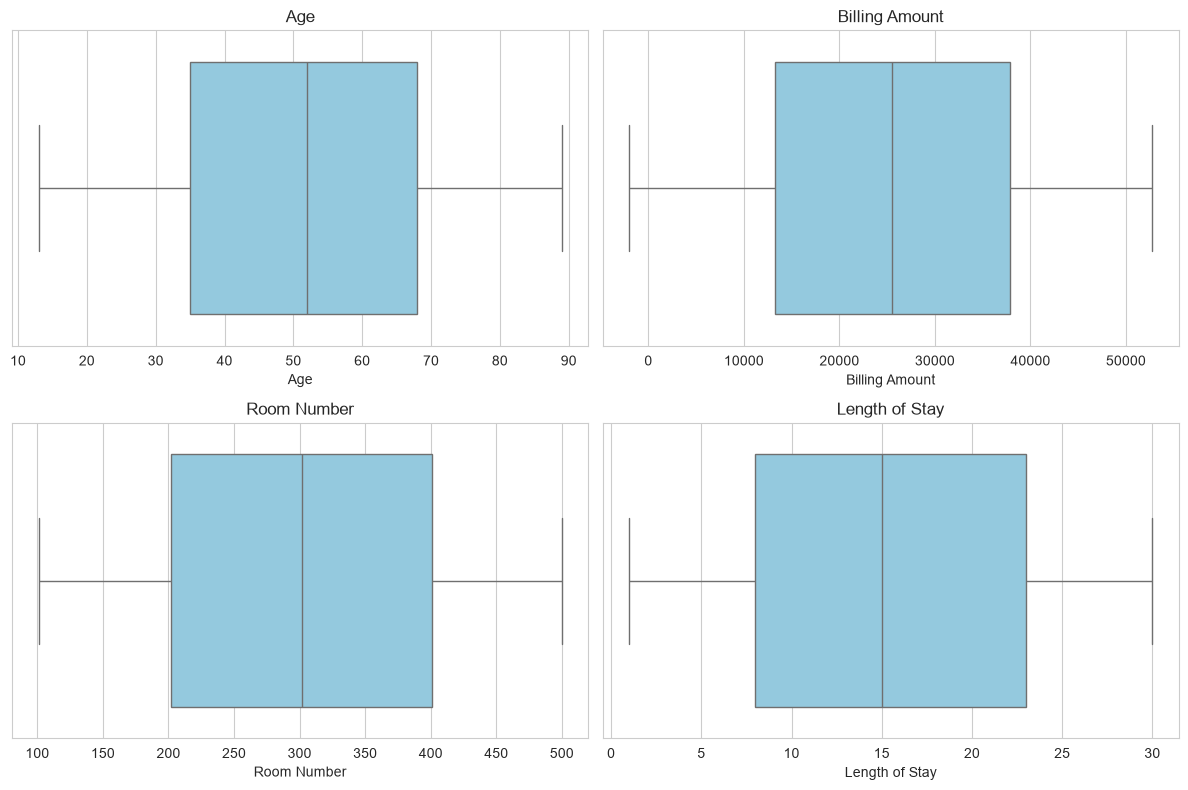

In [56]:
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for ax, col in zip(axes, numeric_cols):
    sns.boxplot(x=df[col], ax=ax, color='skyblue')
    ax.set_title(col)
plt.tight_layout()
plt.show()

**Reading the box plots:**

- `Age` and `Room Number` show no points beyond the whiskers, confirming the IQR table above where these columns had zero flagged outliers.
- `Billing Amount` shows points below the lower whisker, corresponding to negative bill values.
- `Length of Stay` may show points above the upper whisker for admissions with unusually long durations.

### 4.4 Scatter Plot

Scatter plots are more useful for spotting outliers in relation to another variable, which moves into multivariate analysis. A simple index-based scatter can still highlight isolated univariate extremes.

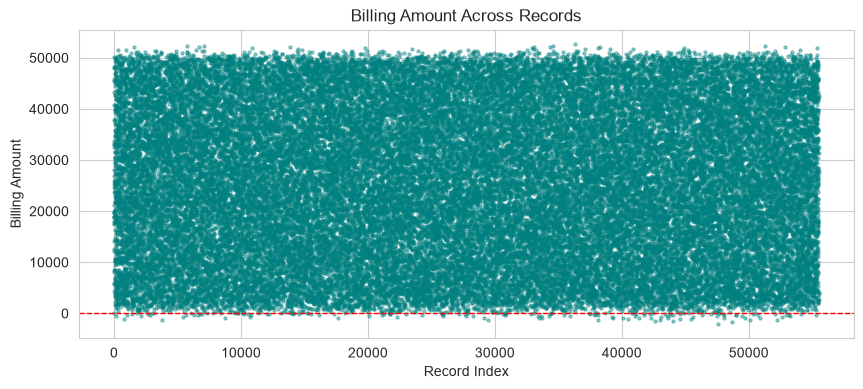

In [57]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.scatter(range(len(df)), df['Billing Amount'], s=5, alpha=0.4, color='teal')
ax.axhline(0, color='red', linestyle='--', linewidth=1)
ax.set_xlabel('Record Index')
ax.set_ylabel('Billing Amount')
ax.set_title('Billing Amount Across Records')
plt.show()

## 5. Multivariate Outliers

Multivariate outlier detection looks at combinations of variables. A record can look normal on each variable individually but be unusual in how the variables relate to each other, for example a very short Length of Stay combined with a very high Billing Amount.

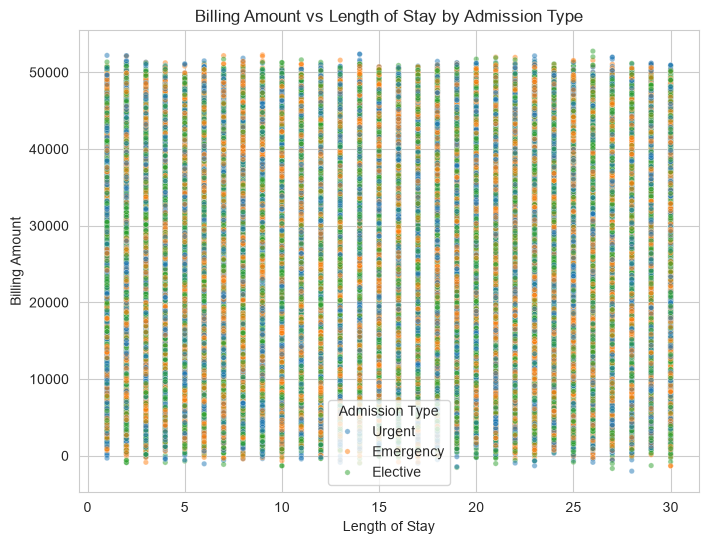

In [58]:
fig, ax = plt.subplots(figsize=(8, 6))
sns.scatterplot(data=df, x='Length of Stay', y='Billing Amount', hue='Admission Type', alpha=0.5, s=15, ax=ax)
ax.set_title('Billing Amount vs Length of Stay by Admission Type')
plt.show()

In [59]:
age_bins = pd.cut(df['Age'], bins=[0, 18, 35, 50, 65, 100])
billing_by_age = df.groupby(age_bins, observed=True)['Billing Amount'].agg(['mean', 'std', 'count'])
billing_by_age

,mean,std,count
Age,,,
"(0, 18]",26757.742344,14288.121539,888
"(18, 35]",25522.270144,14183.834341,13644
"(35, 50]",25522.145077,14311.589550,12301
"(50, 65]",25640.009180,14179.007768,12417
"(65, 100]",25423.102385,14177.213408,16250


In [60]:
df['billing_z_within_age_group'] = df.groupby(age_bins, observed=True)['Billing Amount'].transform(
    lambda x: (x - x.mean()) / x.std()
)
multivariate_outliers = df[df['billing_z_within_age_group'].abs() > 3]
len(multivariate_outliers)

0

A record flagged here has a Billing Amount that is extreme relative to patients of a similar age, even if it would not be flagged as extreme against the full dataset. This is the essence of a multivariate outlier.

## 6. Investigating the Flagged Outliers

Rather than deleting every flagged row, each group of outliers is examined for a plausible explanation.

### 6.1 Billing Amount - Negative Values

Negative billing amounts are almost certainly a data-entry or system error, since a medical bill cannot logically be negative in this context (it is not modeled as a refund field).

In [61]:
negative_billing = df[df['Billing Amount'] < 0]
print(f"Negative billing records: {len(negative_billing)}")
negative_billing[['Age', 'Medical Condition', 'Billing Amount', 'Admission Type']].head(10)

Negative billing records: 108


,Age,Medical Condition,Billing Amount,Admission Type
132,32,Cancer,-502.507813,Urgent
799,49,Asthma,-1018.245371,Elective
1018,60,Hypertension,-306.364925,Elective
1421,74,Asthma,-109.097122,Emergency
2103,72,Diabetes,-576.727907,Urgent
2696,74,Diabetes,-135.986000,Elective
2855,39,Hypertension,-370.983674,Elective
3772,77,Obesity,-1310.272895,Elective
5445,32,Arthritis,-692.408820,Elective
5708,23,Diabetes,-353.865186,Elective


**Reasoning:**
- Is it genuine? No - a negative charge does not correspond to any documented billing scenario in this dataset.
- Is it a data-entry error? Most likely, e.g. a sign flipped during entry or export.
- Should it be removed? Not necessarily - removing rows loses information in every other column.
- **Decision:** Treat the sign as an error and take the absolute value, or set to NaN and impute if the magnitude itself is also unreliable. Absolute value is used below since the rest of the record appears otherwise valid.

In [62]:
df['Billing Amount Cleaned'] = df['Billing Amount'].abs()
df[['Billing Amount', 'Billing Amount Cleaned']].loc[negative_billing.index].head()

,Billing Amount,Billing Amount Cleaned
132,-502.507813,502.507813
799,-1018.245371,1018.245371
1018,-306.364925,306.364925
1421,-109.097122,109.097122
2103,-576.727907,576.727907


### 6.2 Billing Amount - Extreme High Values

High bills flagged by IQR are checked against Medical Condition and Admission Type to see whether the cost is plausible.

In [63]:
lower, upper = iqr_bounds(df['Billing Amount'])
high_billing = df[df['Billing Amount'] > upper]
print(f"High billing records: {len(high_billing)}")
high_billing['Medical Condition'].value_counts()

High billing records: 0


Series([], Name: count, dtype: int64)

**Reasoning:**
- Is it genuine? High billing values are spread across multiple medical conditions rather than concentrated in one implausible category, which is consistent with real variation in treatment cost.
- Is it a data-entry error? No obvious sign of that (no impossible values, no duplicated digits pattern).
- Is it an unusual but valid observation? Yes - complex or extended treatments can legitimately cost more.
- **Decision:** Retain as-is. These are valid extreme values that reflect real cost variation, not errors.

### 6.3 Age

The IQR and Z-Score checks reported zero outliers for Age, and the box plot confirms no points beyond the whiskers.

In [64]:
print(df['Age'].min(), df['Age'].max())

13 89


**Reasoning:**
- The recorded age range is entirely within a plausible human range for hospital admissions.
- **Decision:** No action needed. Age requires no outlier treatment in this dataset.

### 6.4 Room Number

Room Number is a categorical identifier stored as a number, not a measured quantity, so statistical outlier bounds are not meaningful for it even though IQR technically returns none.

In [65]:
df['Room Number'].agg(['min', 'max', 'nunique'])

min        101
max        500
nunique    400
Name: Room Number, dtype: int64

**Reasoning:**
- Room Number represents an identifier, not a continuous measurement, so the concept of a statistical outlier does not apply in the usual sense.
- **Decision:** Exclude Room Number from outlier treatment entirely; it should only be validated for referential correctness (e.g. does it exist in the hospital's room list), which is outside the scope of statistical outlier analysis.

### 6.5 Length of Stay

Extended lengths of stay are checked against Medical Condition to see if they cluster around conditions that plausibly require longer hospitalization.

In [66]:
lower, upper = iqr_bounds(df['Length of Stay'])
long_stay = df[df['Length of Stay'] > upper]
print(f"Long stay records: {len(long_stay)}, upper bound: {upper}")
long_stay['Medical Condition'].value_counts() if len(long_stay) > 0 else 'No records above upper bound'

Long stay records: 0, upper bound: 45.5


'No records above upper bound'

**Reasoning:**
- If long stays are spread across conditions rather than isolated to one, and durations remain within a realistic range for hospital care, they are treated as genuine variation.
- Is it an unusual but valid observation? Likely yes, given plausible upper bounds for hospital stays.
- **Decision:** Retain. Flag for downstream models as a feature that may need transformation (e.g. log transform) rather than removal, since it carries real information.

### 6.6 Multivariate Billing-by-Age Outliers

Records with a Billing Amount far from the norm for their age group deserve a closer look, since these could reflect either legitimate complex cases or entry errors that a single-variable check would miss.

In [67]:
multivariate_outliers[['Age', 'Medical Condition', 'Billing Amount', 'billing_z_within_age_group']].head(10)

,Age,Medical Condition,Billing Amount,billing_z_within_age_group


**Reasoning:**
- These records were not flagged by the univariate IQR test on Billing Amount alone, meaning their values are extreme only relative to their age peer group.
- Is it genuine? Needs case-by-case judgement based on Medical Condition; a young patient with a very high bill could reflect a serious or rare condition.
- **Decision:** Retain, but tag with a flag column so any downstream model or report can account for this segment separately rather than silently averaging it in.

In [68]:
df['is_multivariate_billing_outlier'] = df.index.isin(multivariate_outliers.index)
df['is_multivariate_billing_outlier'].sum()

np.int64(0)